Load and Inspect Data Set

In [12]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
df=pd.read_csv('../data/Tlab.csv')
df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [13]:
df.shape


(6362620, 11)

In [14]:
df.shape
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


np.int64(0)

In [15]:
print(df.shape)

(6362620, 11)


In [16]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head())

Shape: (6362620, 11)

Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

Data Types:
 step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

First 5 rows:
    step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newba

Lets check for duplicated or missings values in the dataset

In [18]:
 df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [ ]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 0


We do not have any missing values or duplicate rows!

In [22]:
print("\nTransaction Types:\n", df['type'].value_counts())
df['isFraud'].value_counts()
print("\nFraud Percentage: {:.4f}%".format(df['isFraud'].mean() * 100))


Transaction Types:
 type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

Fraud Percentage: 0.1291%


## Univariate Analysis ##

Let us see what type of transactions have been labeled as fraud and what type of transactions have been labeled as non-fraud

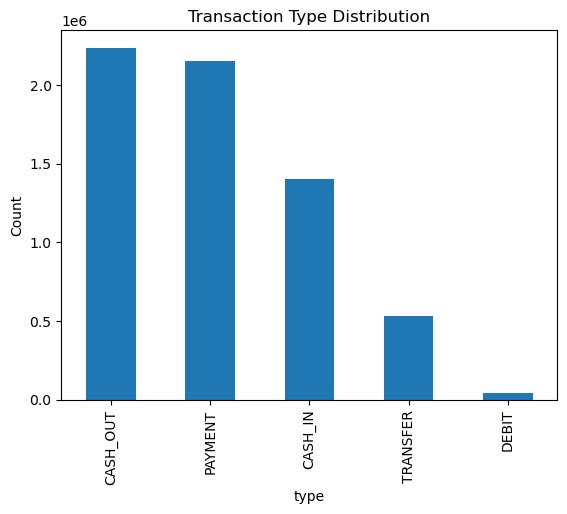

In [47]:
df['type'].value_counts().plot(kind='bar',)
plt.title('Transaction Type Distribution')
plt.ylabel('Count')
plt.show()

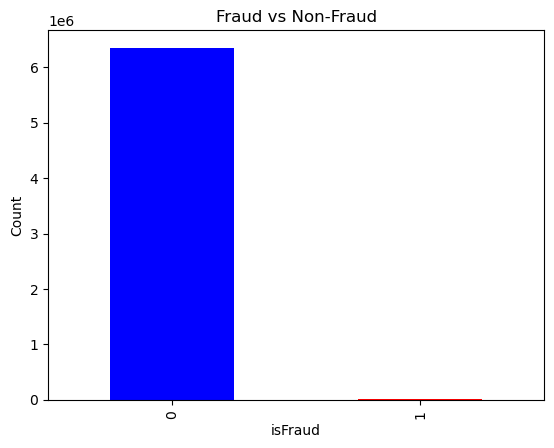

In [50]:
df['isFraud'].value_counts().plot(kind='bar',color=["blue","red"] )
plt.title('Fraud vs Non-Fraud')
plt.ylabel('Count')
plt.show()

Based on the fraud distribution the amount of transactions labeled as "fraud" by the naive model previous used is miniscule compared to the amount of transactions labeled as "not fraud" in a 6.3 million data set. This lets us know that further down the line we need to account for this bias in the model

Next let us see what the distribution of the amounts in each transaction is 

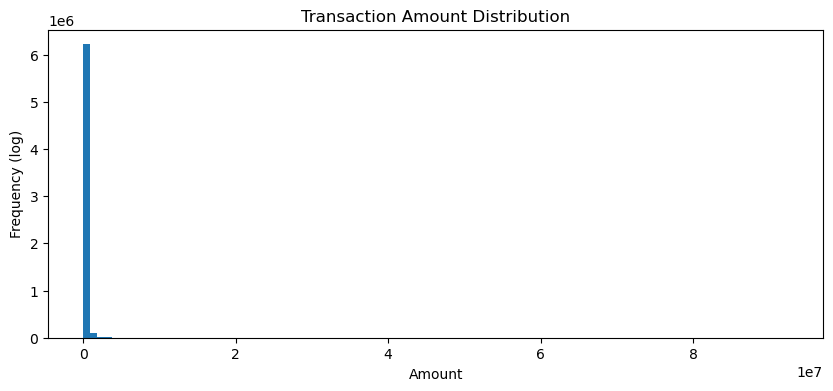

In [45]:
plt.figure(figsize=(10, 4))
plt.hist(df['amount'], bins=100,)
plt.title('Transaction Amount Distribution')
plt.xlabel('Amount')
plt.ylabel('Frequency (log)')
plt.show()

Lets apply the log function to visualize the shape better

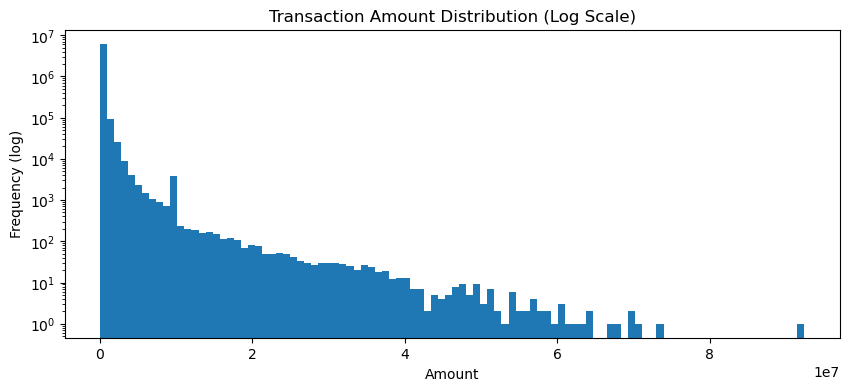

In [44]:

plt.figure(figsize=(10, 4))
plt.hist(df['amount'], bins=100, log=True)
plt.title('Transaction Amount Distribution (Log Scale)')
plt.xlabel('Amount')
plt.ylabel('Frequency (log)')
plt.show()

The graph is skewed to the left showing that most transacations are smaller

## Bivariate ##

In [86]:
Now lets find out how much fraud was detected within each transaction type regardless of its naitivity.

SyntaxError: invalid syntax (919617952.py, line 1)

In [ ]:
df.groupby('type')['isFraud'].sum()

type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isFraud, dtype: int64

We now see that all FRAUD was detected within CASH_OUT and TRANSFER

Here is a visualization of the above data and also a comparison of how much is detected within CASH_OUT and TRANSFER. Majority of "fraud" is detected within TRANSFER type 

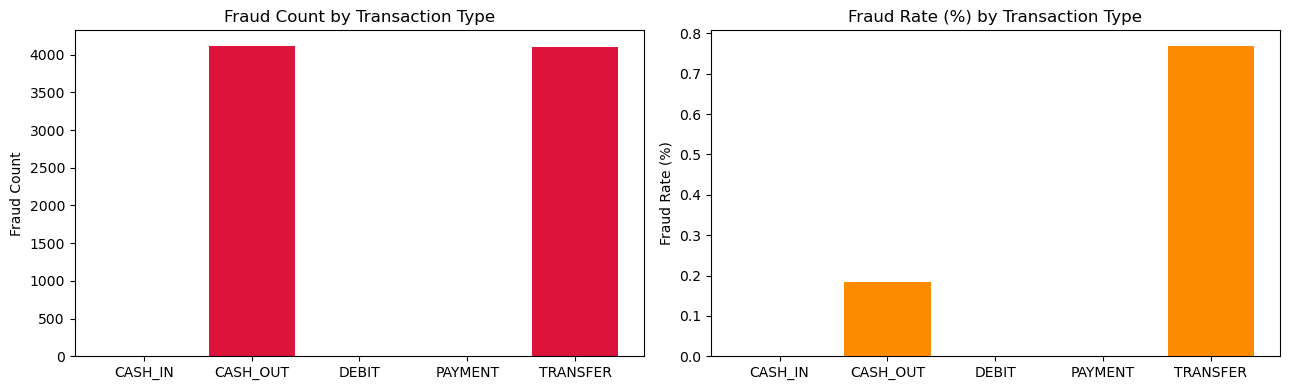

In [ ]:
fraud_in_type = df.groupby('type')['isFraud'].agg(['sum', 'mean']).reset_index()
fraud_in_type.columns = ['type', 'fraud_count', 'fraud_rate']
fraud_in_type['fraud_rate'] *= 100

fig, axes = plt.subplots(1,2, figsize=(13, 4))
axes[0].bar(fraud_in_type['type'], fraud_in_type['fraud_count'], color='crimson')
axes[0].set_title('Fraud Count by Transaction Type')
axes[0].set_ylabel('Fraud Count')

axes.bar(fraud_in_type['type'], fraud_in_type['fraud_rate'], color='darkorange')
axes[1].set_title('Fraud Rate (%) by Transaction Type')
axes[1].set_ylabel('Fraud Rate (%)')
plt.tight_layout()
plt.show()

Lets compare Fraud vs Transacation Amount now.

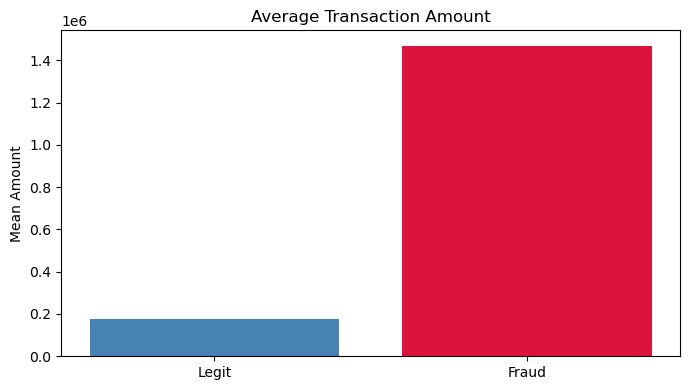

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
mean_amounts = df.groupby('isFraud')['amount'].mean()
ax.bar(['Legit', 'Fraud'], mean_amounts.values, color=['steelblue', 'crimson'])
ax.set_title('Average Transaction Amount')
ax.set_ylabel('Mean Amount')
plt.tight_layout()
plt.show()


We can see that higher the mean of a transaction amount the more likely it will be labled as fraud.

Let's compare newbalanceOrig vs Fraud to see if there is a realtionship that drains the account to 0

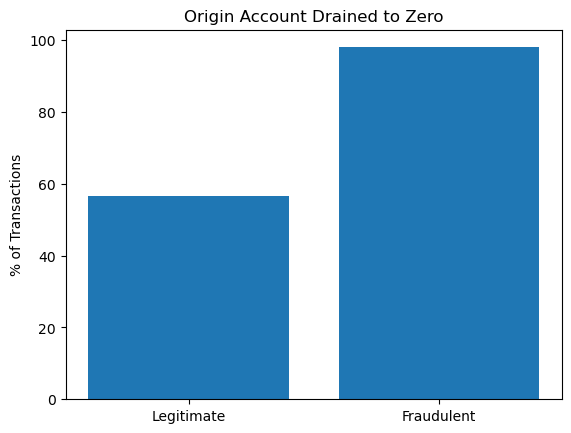

In [ ]:
fraud = df[df['isFraud'] == 1]
legit = df[df['isFraud'] == 0]

pct_fraud_drained = (fraud['newbalanceOrig'] == 0).mean() * 100
pct_legit_drained = (legit['newbalanceOrig'] == 0).mean() * 100

plt.bar(['Legitimate', 'Fraudulent'], 
        [pct_legit_drained, pct_fraud_drained], )

plt.title('Origin Account Drained to Zero')
plt.ylabel('% of Transactions')
plt.show()

There is a higher percentage of Fradulent Accounts that are drained to 0

## Multivariate

Let us see the realtionship between all the features 

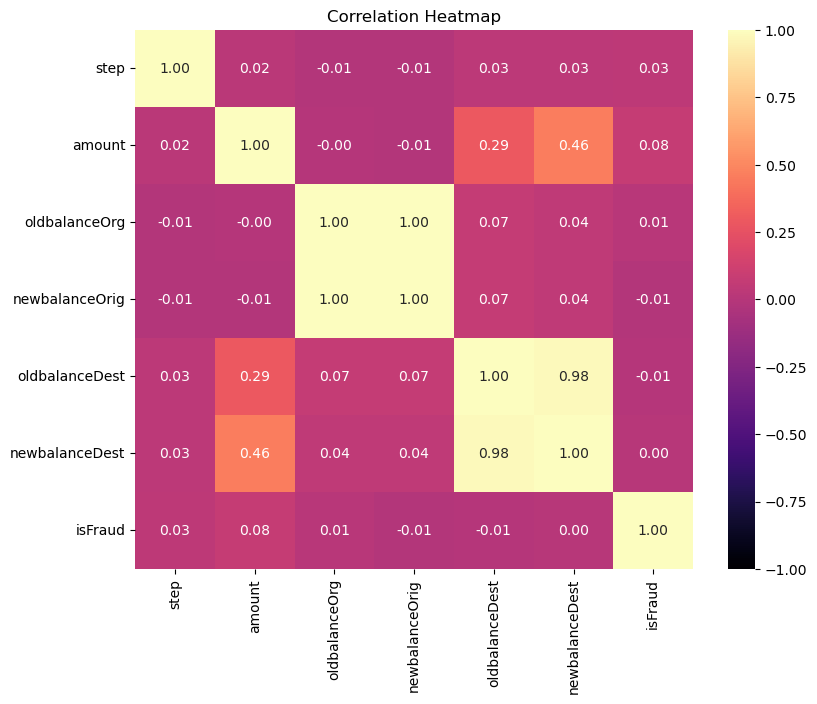

Correlation with isFraud:
amount            0.076688
step              0.031578
oldbalanceOrg     0.010154
newbalanceDest    0.000535
oldbalanceDest   -0.005885
newbalanceOrig   -0.008148
Name: isFraud, dtype: float64


In [ ]:

numeric_cols = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
                'oldbalanceDest', 'newbalanceDest', 'isFraud']

corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='magma',
            vmin=-1, vmax=1,)
plt.title('Correlation Heatmap')
plt.show()

print('Correlation with isFraud:')
print(corr['isFraud'].drop('isFraud').sort_values(ascending=False))

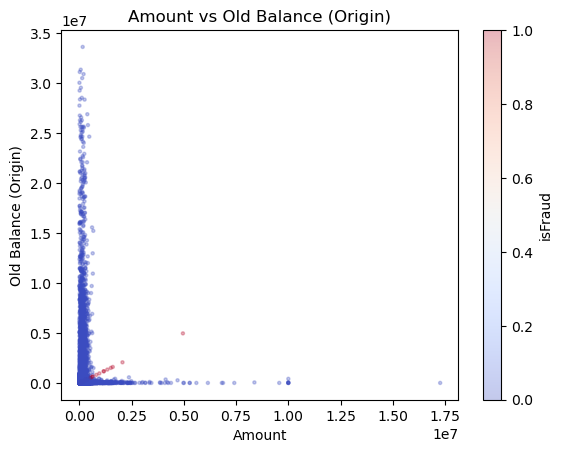

In [105]:
sample = df.sample(10000, random_state=42)

plt.scatter(sample['amount'], sample['oldbalanceOrg'], c=sample['isFraud'], cmap='coolwarm', alpha=0.3, s=5)
plt.title('Amount vs Old Balance (Origin)')
plt.xlabel('Amount')
plt.ylabel('Old Balance (Origin)')
plt.colorbar(label='isFraud')
plt.show()